# Ocean Color Satellites and Data Products

In remote sensing, **ocean color** refers to products derived from optical sensors that observe changes in the water column. The most common product is chlorophyll-a concentration, but ocean color sensors can also support products related to aerosols, clouds, CDOM, turbidity, fluorescence, photosynthetically available radiation, and sea surface temperature.

In [6]:
satellites = pd.DataFrame({
    'Mission / Sensor': ['CZCS', 'SeaWiFS', 'MODIS-Terra', 'MODIS-Aqua', 'VIIRS', 'PACE OCI'],
    'Approx. Years': ['1978-1986', '1997-2010', '1999-2022', '2002-present', '2011-present', '2024-present'],
    'Key Notes': [
        'Proof-of-concept coastal/ocean color mission; about 800 m imagery.',
        '8 visible/NIR bands designed for ocean chlorophyll-a monitoring.',
        'MODIS sensor with many bands for ocean, land, atmosphere, and SST applications.',
        'Major long-running MODIS ocean color data source.',
        'Visible and infrared bands for ocean color, SST, aerosols, and related products.',
        'Hyperspectral ocean color instrument with many narrow bands for ecosystem applications.'
    ]
})
satellites

,Mission / Sensor,Approx. Years,Key Notes
0,CZCS,1978-1986,Proof-of-concept coastal/ocean color mission; ...
1,SeaWiFS,1997-2010,8 visible/NIR bands designed for ocean chlorop...
2,MODIS-Terra,1999-2022,"MODIS sensor with many bands for ocean, land, ..."
3,MODIS-Aqua,2002-present,Major long-running MODIS ocean color data source.
4,VIIRS,2011-present,"Visible and infrared bands for ocean color, SS..."
5,PACE OCI,2024-present,Hyperspectral ocean color instrument with many...


## Nearly Five Decades of Ocean Color Observations

Ocean color observations began with CZCS in the late 1970s. After a gap between CZCS and SeaWiFS, continuous global ocean color observations became much more common with SeaWiFS, MODIS, VIIRS, and now PACE.

PACE is especially important because its Ocean Color Instrument is hyperspectral. With narrow wavelength bands, it provides more spectral detail than traditional multispectral sensors and may improve estimates of phytoplankton community composition.

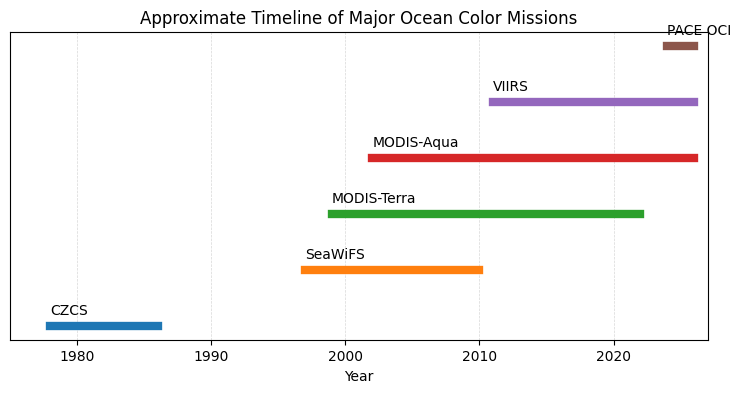

In [7]:
# Simple timeline visualization
missions = [
    ('CZCS', 1978, 1986),
    ('SeaWiFS', 1997, 2010),
    ('MODIS-Terra', 1999, 2022),
    ('MODIS-Aqua', 2002, 2026),
    ('VIIRS', 2011, 2026),
    ('PACE OCI', 2024, 2026),
]

plt.figure(figsize=(9,4))
for i, (name, start, end) in enumerate(missions):
    plt.plot([start, end], [i, i], linewidth=6)
    plt.text(start, i+0.15, name, va='bottom')
plt.yticks([])
plt.xlabel('Year')
plt.title('Approximate Timeline of Major Ocean Color Missions')
plt.grid(axis='x', linestyle='--', linewidth=0.5, alpha=0.5)
plt.xlim(1975, 2027)
plt.show()

## Can All Optical Satellites Estimate Chlorophyll-a?

Not necessarily. A useful chlorophyll-a sensor needs bands that sample the spectral features used by ocean color algorithms, especially blue and green wavelengths. Sensors with broad or poorly placed bands may not separate chlorophyll-a, CDOM, sediment, and atmospheric effects well enough for robust retrievals.

Spatial resolution also matters. A high-resolution sensor may be useful near coasts, but if it does not have the right spectral bands or calibration, it may not produce reliable ocean color products.

## Data from Ocean Color Satellites

Satellite products are commonly organized into processing levels. Higher-level products are usually easier to use because they have already been geolocated, atmospherically corrected, converted into geophysical variables, and sometimes mapped to a regular grid.

In [8]:
levels = pd.DataFrame({
    'Level': ['Level 0', 'Level 1', 'Level 2', 'Level 3', 'Level 4'],
    'Description': [
        'Unprocessed engineering data from the satellite.',
        'Swath data with geolocation and metadata.',
        'Geophysical products derived from Level 1 data, still in swath format.',
        'Level 2 products mapped onto a common grid.',
        'Products combined with numerical models or additional analysis.'
    ],
    'Example': [
        'Raw instrument telemetry',
        'Calibrated radiances with latitude/longitude',
        'Chlorophyll-a, CDOM, fluorescence, PAR',
        'Daily or monthly gridded chlorophyll-a',
        'Gap-filled or model-assimilated biogeochemical fields'
    ]
})
levels

,Level,Description,Example
0,Level 0,Unprocessed engineering data from the satellite.,Raw instrument telemetry
1,Level 1,Swath data with geolocation and metadata.,Calibrated radiances with latitude/longitude
2,Level 2,Geophysical products derived from Level 1 data...,"Chlorophyll-a, CDOM, fluorescence, PAR"
3,Level 3,Level 2 products mapped onto a common grid.,Daily or monthly gridded chlorophyll-a
4,Level 4,Products combined with numerical models or add...,Gap-filled or model-assimilated biogeochemical...


## Common Level 3 Ocean Color Products

Common gridded ocean color products include:

- **Chlorophyll-a concentration** (`mg m^{-3}`)
- **CDOM absorption** (`m^{-1}`)
- **Fluorescence line height** (`W m^{-2} µm^{-1} sr^{-1}`)
- **Photosynthetically Available Radiation**, or PAR (`Einstein m^{-2} day^{-1}`)
- **Sea surface temperature**, from infrared bands (`°C`)

Level 3 products are useful for mapping and time-series analysis, but users should always check quality flags, masks, spatial resolution, temporal resolution, and processing version.

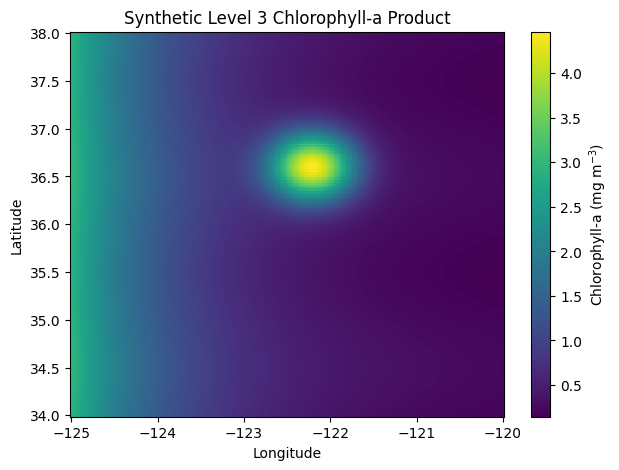

In [9]:
# Create a synthetic gridded chlorophyll-a map for demonstration
lon = np.linspace(-125, -120, 180)
lat = np.linspace(34, 38, 140)
LON, LAT = np.meshgrid(lon, lat)

coastal_gradient = 2.8 * np.exp(-(LON + 125)/1.2)
bloom = 4.0 * np.exp(-((LON + 122.2)**2/(2*0.35**2) + (LAT - 36.6)**2/(2*0.25**2)))
offshore = 0.15 + 0.05*np.sin((LAT-34)*np.pi)
chl_grid = offshore + coastal_gradient + bloom

plt.figure(figsize=(7,5))
pm = plt.pcolormesh(lon, lat, chl_grid, shading='auto')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Synthetic Level 3 Chlorophyll-a Product')
cb = plt.colorbar(pm)
cb.set_label('Chlorophyll-a (mg m$^{-3}$)')
plt.show()

### Check Your Understanding

1. Why are Level 3 products often easier for users than Level 2 products?
2. What information might be lost when swath data are mapped to a regular grid?
3. Why should you check quality flags before interpreting a chlorophyll-a map?